In [23]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv("iris.csv")

In [24]:
# Input features as x and y
X = df[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']]
y = df['Species']

In [25]:
# fitting of model
le = LabelEncoder()
y = le.fit_transform(y)

In [26]:
# splitting of data into a training and testing sets
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

In [27]:
# Standardization of features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [28]:
#creating a Train model
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,200
,multi_class,'deprecated'


In [29]:
#Predicted values
y_pred = model.predict(X_test)
print(y_pred)


[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]


In [30]:
#Accuracy and classification report
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=le
    .classes_))

Accuracy: 1.00

Classification Report:
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



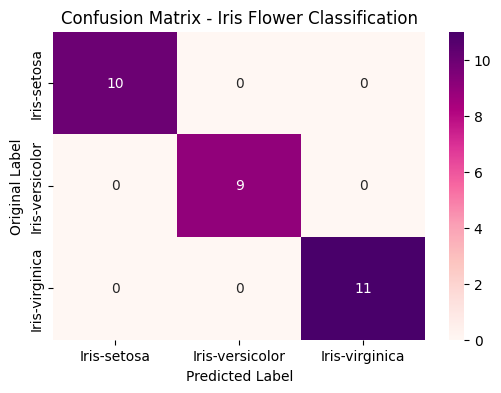

In [31]:
# Visualization of confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, cmap='RdPu', fmt='d', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion Matrix - Iris Flower Classification")
plt.xlabel("Predicted Label")
plt.ylabel("Original Label")
plt.show()

In [32]:
# Step 9: Decision Boundary Visualization of Sepal Length vs Sepal Width
X_visual = X[['SepalLengthCm', 'SepalWidthCm']].values
X_visual = StandardScaler().fit_transform(X_visual)
y_visual = y

model_visual = LogisticRegression(max_iter=200)
model_visual.fit(X_visual, y_visual)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,200
,multi_class,'deprecated'


In [33]:
# Define grid
x_min, x_max = X_visual[:, 0].min() - 1, X_visual[:, 0].max() + 1
y_min, y_max = X_visual[:, 1].min() - 1, X_visual[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),np.arange(y_min, y_max, 0.02))


In [34]:
# Predict for each grid point
Z = model_visual.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

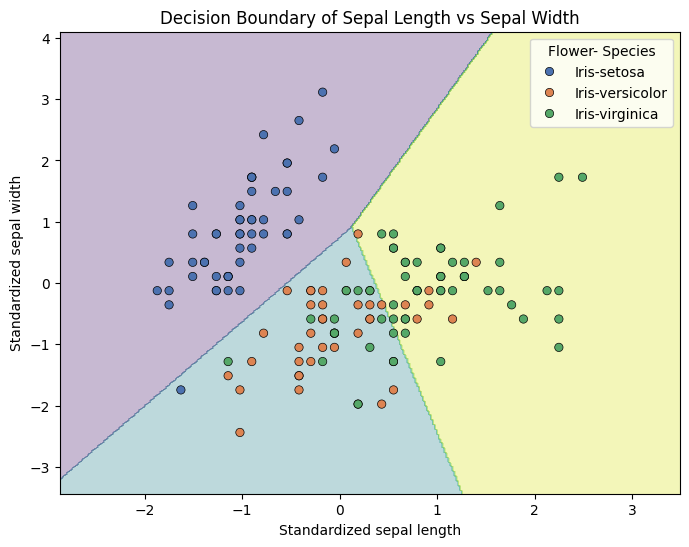

In [36]:
# Ploting of decision boundary
plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
sns.scatterplot(x=X_visual[:, 0], y=X_visual[:, 1], hue=le.inverse_transform(y_visual),
                palette='deep', edgecolor='k')
plt.title("Decision Boundary of Sepal Length vs Sepal Width")
plt.xlabel("Standardized sepal length")
plt.ylabel("Standardized sepal width")
plt.legend(title="Flower- Species")
plt.show()
